# Análisis comparativo — Conti · Black Basta · LockBit · Exploit.in

Compara el estilo semántico de los actores de los 4 grupos usando  
los embeddings generados en los módulos 03 de cada uno.

**Fundamento**: todos los datasets se embebieron con `qwen3-embedding` →  
los vectores viven en el **mismo espacio de 4096 dimensiones** →  
la similitud coseno entre actores de distintos grupos es matemáticamente comparable.

| Grupo | Tipo de dato | Periodo | Actores |
|---|---|---|---|
| Conti | Chats internos filtrados | 2020–2022 | 30 |
| Black Basta | Chats internos filtrados | 2023–2024 | 47 |
| LockBit | Panel de negociación (operadores) | dic 2024–abr 2025 | 20 |
| Exploit.in | Foro underground ruso | 2005–2008 | 156 |

Requiere haber ejecutado los notebooks `03_embeddings` de cada módulo.

## 0. Setup

In [1]:
# ─── IMPORTACIONES ───────────────────────────────────────────────────────────
# Aquí cargamos todas las "herramientas" (librerías) que necesitaremos.
# Python no incluye estas capacidades por defecto; hay que pedirlas explícitamente.

# json es la librería estándar de Python para leer y escribir archivos JSON.
# Los perfiles de los actores están guardados en ese formato (listas y diccionarios de texto).
import json

# numpy es la librería de cálculo numérico de Python.
# La usamos para trabajar con matrices de números grandes, como los embeddings.
# Un embedding es un vector de 4096 números que representan el "significado" de un texto.
import numpy as np

# pandas es la librería para trabajar con tablas de datos (como Excel pero en código).
# Un "DataFrame" es una tabla con filas y columnas que podemos filtrar, agrupar y calcular.
import pandas as pd

# matplotlib es la librería principal de gráficos en Python.
# "plt" es el módulo de gráficos (scatter plots, histogramas, heatmaps...).
# "mpatches" permite crear elementos de leyenda manualmente (rectángulos de color).
# "Line2D" sirve para añadir líneas personalizadas a las leyendas.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# umap (Uniform Manifold Approximation and Projection) es un algoritmo que toma
# vectores de muchas dimensiones (aquí, 4096) y los comprime a solo 2 dimensiones
# para poder visualizarlos en un plano. Mantiene la estructura: puntos similares
# en 4096D quedan cerca también en 2D.
import umap

# pathlib.Path es la forma moderna en Python de manejar rutas de archivos.
# En lugar de escribir strings como '../carpeta/archivo.npy', usamos objetos Path
# que funcionan igual en Windows, Mac y Linux, y permiten concatenar rutas con '/'.
from pathlib import Path

# cosine_similarity calcula qué tan parecidos son dos vectores numéricos.
# Resultado: 1.0 = idénticos, 0.0 = sin relación, -1.0 = completamente opuestos.
# Es la medida perfecta para comparar embeddings porque no depende de la longitud
# del texto, solo de la "dirección" del vector (es decir, el estilo semántico).
from sklearn.metrics.pairwise import cosine_similarity

# display es una función de Jupyter que muestra objetos (como tablas de pandas)
# con formato HTML más bonito que el print() normal.
from IPython.display import display

# ─── DIRECTORIO BASE ──────────────────────────────────────────────────────────
# Definimos la ruta base del proyecto. '..' significa "un nivel arriba" del
# directorio actual. Como este notebook está en 'comparative/', subimos un nivel
# para llegar a la raíz del proyecto donde están las carpetas de cada grupo.
BASE = Path('..')

# ─── RUTAS DE ARCHIVOS ────────────────────────────────────────────────────────
# Definimos las rutas a todos los archivos que necesitamos, grupo por grupo.
# Hay tres tipos de archivos por grupo:
#   - _EMB    : archivo .npy con los embeddings (matriz de vectores numéricos)
#   - _SAMPLE : archivo .parquet con la tabla de mensajes (quién escribió qué)
#   - _PROFILES: archivo .json con el perfil LLM de cada actor (rol, especialidad...)
# El operador '/' entre dos objetos Path los concatena en una nueva ruta.

# Grupo Conti (chats internos filtrados 2020-2022)
CONTI_EMB      = BASE / 'data_Vruto/ContiLeaks/message_embeddings.npy'
CONTI_SAMPLE   = BASE / 'data_Vruto/ContiLeaks/conti_sample_with_embeddings.parquet'
CONTI_PROFILES = BASE / 'data_Vruto/ContiLeaks/actor_profiles.json'

# Grupo Black Basta (chats internos filtrados 2023-2024)
BB_EMB         = BASE / 'data_Vruto/BlackBasta/bb_message_embeddings.npy'
BB_SAMPLE      = BASE / 'data_Vruto/BlackBasta/bb_sample_with_embeddings.parquet'
BB_PROFILES    = BASE / 'data_Vruto/BlackBasta/bb_actor_profiles.json'

# Grupo LockBit (panel de negociación dic 2024 – abr 2025).
# LockBit tiene además un archivo de usuarios para traducir IDs numéricos a logins legibles.
LK_EMB         = BASE / 'data_Vruto/LockBit/chat_embeddings.npy'
LK_SAMPLE      = BASE / 'data_Vruto/LockBit/chats_with_embeddings.parquet'
LK_PROFILES    = BASE / 'data_Vruto/LockBit/operator_profiles.json'
LK_USERS       = BASE / 'data_Vruto/LockBit/users.parquet'

# Grupo Exploit.in (foro underground ruso 2005-2008)
EI_EMB         = BASE / 'data_Vruto/ExploitIn/exploitin_message_embeddings.npy'
EI_SAMPLE      = BASE / 'data_Vruto/ExploitIn/exploitin_sample_with_embeddings.parquet'
EI_PROFILES    = BASE / 'data_Vruto/ExploitIn/exploitin_user_profiles.json'

# ─── VERIFICACIÓN DE ARCHIVOS ─────────────────────────────────────────────────
# Antes de cargar nada, comprobamos que todos los archivos existen en disco.
# "assert condición, mensaje" lanza un error claro con ese mensaje si la condición
# es False. Así detectamos inmediatamente si falta algún archivo, en lugar de
# recibir un error confuso más adelante cuando intentemos usarlo.
for p in [CONTI_EMB, CONTI_SAMPLE, CONTI_PROFILES,
           BB_EMB, BB_SAMPLE, BB_PROFILES,
           LK_EMB, LK_SAMPLE, LK_PROFILES, LK_USERS,
           EI_EMB, EI_SAMPLE, EI_PROFILES]:
    assert p.exists(), f'Falta: {p}'

# ─── CARGAR EMBEDDINGS ────────────────────────────────────────────────────────
# np.load() carga archivos .npy (formato binario de numpy, mucho más rápido que CSV).
# El resultado es una matriz 2D: cada fila es un mensaje, cada columna es una de las
# 4096 dimensiones del embedding. Por ejemplo, conti_emb tendrá forma (1500, 4096):
# 1500 mensajes × 4096 valores numéricos por embedding.
conti_emb = np.load(CONTI_EMB)
bb_emb    = np.load(BB_EMB)
lk_emb    = np.load(LK_EMB)
ei_emb    = np.load(EI_EMB)

# ─── CARGAR TABLAS DE MENSAJES ────────────────────────────────────────────────
# pd.read_parquet() carga archivos .parquet, un formato columnar muy eficiente
# (más rápido y compacto que CSV para tablas grandes).
# reset_index(drop=True) reinicia los índices de fila desde 0. Esto es crítico:
# la fila i de la tabla debe corresponder exactamente a la fila i de la matriz
# de embeddings (para saber qué embedding pertenece a qué mensaje).
conti_msgs = pd.read_parquet(CONTI_SAMPLE).reset_index(drop=True)
bb_msgs    = pd.read_parquet(BB_SAMPLE).reset_index(drop=True)
lk_msgs    = pd.read_parquet(LK_SAMPLE).reset_index(drop=True)
ei_msgs    = pd.read_parquet(EI_SAMPLE).reset_index(drop=True)
lk_users   = pd.read_parquet(LK_USERS)  # Tabla de usuarios de LockBit (ID → login)

# ─── CARGAR PERFILES JSON ─────────────────────────────────────────────────────
# Los perfiles son diccionarios JSON generados por un LLM a partir de los mensajes
# de cada actor. Contienen campos como 'role' o 'specialty' que describen
# la función de ese actor dentro del grupo criminal o del foro.
# La sintaxis "with open(...) as f:" abre el archivo y lo cierra automáticamente al terminar.
# json.load(f) convierte el texto JSON en un diccionario de Python.
with open(CONTI_PROFILES)  as f: conti_profiles = json.load(f)
with open(BB_PROFILES)     as f: bb_profiles    = json.load(f)
with open(LK_PROFILES)     as f: lk_profiles    = json.load(f)
with open(EI_PROFILES)     as f: ei_profiles    = json.load(f)

# ─── MAPA ID → LOGIN PARA LOCKBIT ─────────────────────────────────────────────
# En LockBit, los mensajes identifican a los operadores por su ID numérico (advid),
# no por su nombre de usuario (login). Creamos un diccionario de traducción:
# zip() empareja los dos campos columna a columna, y dict() lo convierte en diccionario.
# Ejemplo resultado: {12345: 'amleto', 67890: 'king457533579', ...}
advid_to_login = dict(zip(lk_users['id'], lk_users['login']))

# ─── VERIFICACIÓN FINAL ───────────────────────────────────────────────────────
# Imprimimos un resumen de lo cargado para confirmar que todo es correcto.
# .shape devuelve (número_de_filas, número_de_columnas) de una matriz numpy.
# .nunique() cuenta cuántos valores únicos hay en una columna de pandas.
# lk_msgs[lk_msgs.flag==1] filtra solo los mensajes de operadores (no de víctimas).
print(f'Conti    : {conti_emb.shape}  — {conti_msgs.username.nunique()} actores')
print(f'BlackBasta: {bb_emb.shape}  — {bb_msgs.username.nunique()} actores')
print(f'LockBit  : {lk_emb.shape}  — {lk_msgs[lk_msgs.flag==1].advid.nunique()} operadores')
print(f'ExploitIn: {ei_emb.shape}  — {ei_msgs.username.nunique()} autores ({len(ei_profiles)} perfilados)')
print(f'\nEspacio vectorial compartido: {conti_emb.shape[1]}D  ✅')

Conti    : (2520, 4096)  — 30 actores
BlackBasta: (3598, 4096)  — 47 actores
LockBit  : (3977, 4096)  — 29 operadores
ExploitIn: (5289, 4096)  — 1081 autores (156 perfilados)

Espacio vectorial compartido: 4096D  ✅


## 1. Centroides de actores

Media L2-normalizada de los embeddings de cada actor.  
LockBit: solo mensajes de operadores (`flag=1`), mapeados a su login.

In [2]:
# ─── FUNCIÓN: CALCULAR CENTROIDES DE ACTORES ──────────────────────────────────
# Un "centroide" es el promedio de todos los vectores (embeddings) de un actor.
# Imagina que cada mensaje es un punto en un espacio de 4096 dimensiones.
# El centroide es el "centro de masa" de todos esos puntos: un único vector
# que resume el estilo de escritura típico del actor.
# Usamos el centroide para representar a cada actor con un solo vector,
# en lugar de tener que manejar cientos de mensajes individuales.

def compute_centroids(msgs_df, embeddings, actor_col='username', min_posts=5):
    """Centroide L2-normalizado por actor. msgs_df debe tener reset_index."""
    # centroids será el resultado: un diccionario {nombre_actor: vector_centroide}
    centroids = {}

    # groupby() agrupa las filas de la tabla por el valor de actor_col.
    # En cada iteración, "actor" es el nombre del actor y "group" es la sub-tabla
    # con todos los mensajes de ese actor (sus filas de la tabla original).
    for actor, group in msgs_df.groupby(actor_col):

        # Filtramos actores con muy pocos mensajes: con solo 1-4 mensajes,
        # el centroide no sería representativo del estilo real del actor.
        # Descartamos estos actores continuando al siguiente con "continue".
        if len(group) < min_posts:
            continue

        # group.index.tolist() obtiene los números de fila de los mensajes de este actor.
        # Como hicimos reset_index() al cargar la tabla, el índice de fila coincide
        # exactamente con la posición en la matriz de embeddings.
        # "vecs" es una sub-matriz de forma (num_mensajes_del_actor, 4096).
        vecs = embeddings[group.index.tolist()]

        # .mean(axis=0) calcula el promedio columna a columna.
        # Es decir, promedia la dimensión 1 de todos los mensajes, luego la 2, etc.
        # Resultado: un único vector de 4096 números (el centroide del actor).
        c = vecs.mean(axis=0)

        # ─── NORMALIZACIÓN L2 ─────────────────────────────────────────────────
        # np.linalg.norm() calcula la "longitud" (norma euclidiana) del vector:
        # raíz cuadrada de la suma de todos los valores al cuadrado.
        # Al dividir el vector por su propia longitud obtenemos un "vector unitario"
        # (longitud = 1). A esto se le llama normalización L2.
        # ¿Por qué normalizamos? Porque la similitud coseno mide el ángulo entre
        # vectores, no su longitud. Normalizar garantiza que comparamos solo
        # "dirección" (estilo semántico) y no "magnitud" (cantidad de texto).
        norm = np.linalg.norm(c)
        if norm > 0:    # Evitar división por cero en el improbable caso de vector nulo
            c /= norm   # Dividimos cada elemento del vector entre su norma

        # Guardamos el centroide normalizado asociado al nombre del actor
        centroids[actor] = c

    return centroids

# ─── CALCULAR CENTROIDES PARA CONTI Y BLACK BASTA ─────────────────────────────
# Estos dos grupos usan la columna 'username' directamente como identificador.
# La función usará el valor por defecto actor_col='username'.
conti_centroids = compute_centroids(conti_msgs, conti_emb)
bb_centroids    = compute_centroids(bb_msgs,    bb_emb)

# ─── CALCULAR CENTROIDES PARA LOCKBIT ─────────────────────────────────────────
# En LockBit hay dos tipos de participantes en los chats:
#   - flag=1 → operadores (miembros del grupo de ransomware, los que nos interesan)
#   - flag=0 → víctimas (empresas negociando el pago del rescate)
# Filtramos con lk_msgs['flag'] == 1 para quedarnos solo con los operadores.
# .copy() crea una copia independiente para evitar advertencias de pandas al modificarla.
lk_ops = lk_msgs[lk_msgs['flag'] == 1].copy()

# Traducimos el ID numérico de cada operador a su nombre de usuario legible,
# usando el diccionario advid_to_login que creamos en la celda anterior.
# .map() aplica esa traducción a toda la columna de una sola vez:
# sustituye cada ID por el login correspondiente en el diccionario.
lk_ops['actor'] = lk_ops['advid'].map(advid_to_login)

# Usamos actor_col='actor' porque la nueva columna con los logins se llama 'actor'.
lk_centroids = compute_centroids(lk_ops, lk_emb, actor_col='actor', min_posts=5)

# ─── CALCULAR CENTROIDES PARA EXPLOIT.IN ──────────────────────────────────────
# Exploit.in tiene más de 1000 usuarios distintos, pero solo tenemos perfiles LLM
# para 156 de ellos (los más activos, analizados en el módulo 03 de ExploitIn).
# .isin(ei_profiles.keys()) devuelve True/False por fila: True si el username
# aparece como clave en el diccionario de perfiles, False en caso contrario.
# Así nos quedamos solo con los usuarios que tienen perfil LLM.
# min_posts=8 es más estricto que los demás grupos porque el foro es más ruidoso.
ei_profiled = ei_msgs[ei_msgs['username'].isin(ei_profiles.keys())].copy()
ei_centroids = compute_centroids(ei_profiled, ei_emb, min_posts=8)

# ─── RESUMEN ──────────────────────────────────────────────────────────────────
# Verificamos cuántos actores quedaron con suficientes mensajes para tener
# un centroide representativo en cada grupo.
print(f'Centroides Conti    : {len(conti_centroids)}')
print(f'Centroides BB       : {len(bb_centroids)}')
print(f'Centroides LockBit  : {len(lk_centroids)}')
print(f'Centroides ExploitIn: {len(ei_centroids)}')
print(f'Total actores       : {len(conti_centroids)+len(bb_centroids)+len(lk_centroids)+len(ei_centroids)}')

Centroides Conti    : 30
Centroides BB       : 47
Centroides LockBit  : 20
Centroides ExploitIn: 156
Total actores       : 253


## 2. Matriz de cohesión 4 × 4

Similitud coseno media intra-grupo vs inter-grupo.  
Revela qué grupos comparten más cultura semántica.

Matriz de cohesión semántica (similitud coseno media):


,Conti,BlackBasta,LockBit,ExploitIn
Conti,0.913,0.921,0.842,0.776
BlackBasta,0.921,0.945,0.869,0.767
LockBit,0.842,0.869,0.905,0.702
ExploitIn,0.776,0.767,0.702,0.864


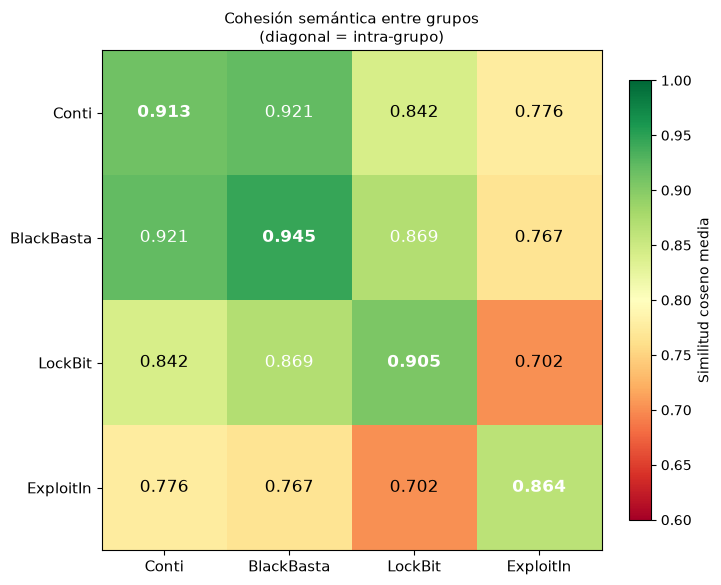

In [3]:
# ─── DICCIONARIO UNIFICADO DE GRUPOS ──────────────────────────────────────────
# Agrupamos los cuatro diccionarios de centroides en uno solo.
# Esto nos permite iterar sobre todos los grupos con un único bucle,
# haciendo el código más limpio y fácil de ampliar si se añaden más grupos.
groups = {
    'Conti':     conti_centroids,
    'BlackBasta':bb_centroids,
    'LockBit':   lk_centroids,
    'ExploitIn': ei_centroids,
}
group_names = list(groups.keys())   # ['Conti', 'BlackBasta', 'LockBit', 'ExploitIn']

# Convertimos cada diccionario de centroides en una matriz numpy 2D.
# list(c.values()) extrae solo los vectores (los valores del diccionario,
# sin las claves/nombres de actor).
# np.array() los apila en una matriz de forma (num_actores, 4096).
# Esto es necesario porque cosine_similarity espera matrices, no listas de vectores.
# El resultado es un diccionario: {'Conti': matriz_30x4096, 'BlackBasta': matriz_47x4096, ...}
group_mats  = {g: np.array(list(c.values())) for g, c in groups.items()}

# ─── CÁLCULO DE LA MATRIZ DE COHESIÓN 4×4 ────────────────────────────────────
# "Cohesión" mide qué tan similares son los actores entre sí dentro de un grupo,
# o entre grupos distintos.
#   - La diagonal (i==j): cohesión INTRA-grupo. ¿Cuánto se parecen los miembros
#     del mismo grupo entre ellos? Un valor alto indica un grupo homogéneo.
#   - Fuera de la diagonal (i!=j): similitud INTER-grupo. ¿Cuánto se parece
#     en promedio el grupo i al grupo j? Valores altos sugieren cultura compartida.

n = len(group_names)   # 4 grupos → matriz 4×4

# np.zeros((n, n)) crea una matriz de ceros de tamaño 4×4 donde iremos
# escribiendo los resultados de similitud uno a uno.
cohesion = np.zeros((n, n))

# Bucle doble para calcular cada celda de la matriz 4×4
for i, gi in enumerate(group_names):
    for j, gj in enumerate(group_names):
        # cosine_similarity(A, B) calcula la similitud entre cada par de filas de A y B.
        # Devuelve una matriz donde el elemento [r, c] es la similitud entre
        # el actor r del grupo A y el actor c del grupo B.
        sim = cosine_similarity(group_mats[gi], group_mats[gj])

        if i == j:
            # ─── COHESIÓN INTRA-GRUPO ─────────────────────────────────────────
            # Si comparamos un grupo consigo mismo, la diagonal de la matriz sim
            # siempre vale 1.0 (cada actor es idéntico a sí mismo: sim(A, A) = 1).
            # Hay que excluirla para obtener la similitud real entre pares distintos.
            # np.triu_indices(N, k=1) devuelve los índices del triángulo superior
            # excluyendo la diagonal (k=1), capturando solo pares únicos (A, B)
            # sin repetir (B, A) ni los pares triviales (A, A).
            idx = np.triu_indices(len(sim), k=1)
            cohesion[i, j] = sim[idx].mean() if len(idx[0]) > 0 else 1.0
        else:
            # ─── SIMILITUD INTER-GRUPO ────────────────────────────────────────
            # Para grupos distintos no hay que excluir ningún par:
            # simplemente promediamos TODOS los pares posibles entre los dos grupos.
            # .mean() sin argumentos promedia todos los elementos de la matriz.
            cohesion[i, j] = sim.mean()

# ─── TABLA DE COHESIÓN ────────────────────────────────────────────────────────
# Convertimos la matriz numpy en un DataFrame de pandas para que muestre
# los nombres de fila y columna, haciéndola más legible.
cohesion_df = pd.DataFrame(cohesion, index=group_names, columns=group_names)
print('Matriz de cohesión semántica (similitud coseno media):')
display(cohesion_df.round(3))   # .round(3) muestra solo 3 decimales

# ─── VISUALIZACIÓN: HEATMAP DE COHESIÓN ──────────────────────────────────────
# Un heatmap es un "mapa de calor": los colores representan valores numéricos.
# Usamos la paleta 'RdYlGn': rojo = similitud baja, amarillo = media, verde = alta.
fig, ax = plt.subplots(figsize=(7, 6))

# imshow() muestra la matriz numpy como una imagen de colores.
# vmin=0.6, vmax=1.0 define el rango de la escala de colores:
# cualquier valor ≤0.6 será rojo oscuro y ≥1.0 será verde oscuro.
im = ax.imshow(cohesion, cmap='RdYlGn', vmin=0.6, vmax=1.0)

# Colocamos los nombres de los grupos como etiquetas en ambos ejes
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(group_names, fontsize=11)
ax.set_yticklabels(group_names, fontsize=11)
ax.set_title('Cohesión semántica entre grupos\n(diagonal = intra-grupo)', fontsize=11)

# Barra de color a la derecha que explica qué color corresponde a qué valor numérico
plt.colorbar(im, ax=ax, fraction=0.04, label='Similitud coseno media')

# ─── ETIQUETAS NUMÉRICAS DENTRO DEL HEATMAP ──────────────────────────────────
# Escribimos el valor exacto dentro de cada celda del heatmap para facilitar la lectura.
# El color del texto cambia según el fondo: blanco sobre celdas oscuras (valor >0.85),
# negro sobre celdas claras, para garantizar siempre contraste suficiente.
# fontweight='bold' en la diagonal destaca los valores de cohesión intra-grupo.
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{cohesion[i,j]:.3f}', ha='center', va='center',
                fontsize=12, color='white' if cohesion[i,j] > 0.85 else 'black',
                fontweight='bold' if i == j else 'normal')

plt.tight_layout()
plt.show()

## 3. UMAP conjunto — todos los actores en el mismo espacio

In [4]:
# ─── SELECCIÓN DE ACTORES PARA EL MAPA UMAP ──────────────────────────────────
# UMAP proyectará todos los centroides en 2D para visualizarlos juntos.
# Exploit.in tiene 156 actores perfilados, lo que haría el gráfico muy denso.
# Limitamos a los top 50 más activos (por número de posts en la muestra)
# para mantener la legibilidad visual del mapa.

# .groupby('username').size() cuenta cuántos mensajes tiene cada usuario.
# .nlargest(50) selecciona los 50 con más mensajes.
# .index.tolist() convierte el índice (que contiene los nombres) en una lista.
ei_top50 = ei_msgs.groupby('username').size().nlargest(50).index.tolist()

# Filtramos además para quedarnos solo con los que tienen centroide calculado.
# (Algunos usuarios activos pueden haberse descartado en compute_centroids
# si tenían menos de 8 posts en la muestra filtrada de perfilados.)
ei_top50 = [a for a in ei_top50 if a in ei_centroids]

# ─── CONSTRUCCIÓN DE LA MATRIZ CONJUNTA ───────────────────────────────────────
# UMAP necesita una única matriz con todos los centroides.
# Usamos cuatro listas paralelas: cada posición i corresponde al mismo actor
# en las cuatro listas (nombre, vector, grupo, rol).
actor_list  = []   # Nombre del actor
vec_list    = []   # Su centroide (vector de 4096 números)
group_list  = []   # A qué grupo pertenece ('Conti', 'BlackBasta', etc.)
role_list   = []   # Su rol o especialidad según el perfil LLM

# ─── AÑADIR ACTORES DE CONTI ──────────────────────────────────────────────────
# .items() en un diccionario devuelve pares (clave, valor), aquí (actor, centroide).
# .get(actor, {}) busca el perfil del actor en el diccionario; si no existe, devuelve
# un diccionario vacío {} para que el segundo .get('role', '?') también funcione.
for actor, c in conti_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('Conti')
    role_list.append(conti_profiles.get(actor, {}).get('role', '?'))

# ─── AÑADIR ACTORES DE BLACK BASTA ────────────────────────────────────────────
for actor, c in bb_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('BlackBasta')
    role_list.append(bb_profiles.get(actor, {}).get('role', '?'))

# ─── AÑADIR ACTORES DE LOCKBIT ────────────────────────────────────────────────
for actor, c in lk_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('LockBit')
    role_list.append(lk_profiles.get(actor, {}).get('role', '?'))

# ─── AÑADIR ACTORES DE EXPLOIT.IN (TOP 50) ────────────────────────────────────
# Para Exploit.in usamos 'specialty' en lugar de 'role' porque el perfil LLM
# de este foro describe la especialidad técnica del usuario (hacking, malware, spam...)
# en vez de su función dentro de una organización criminal.
for actor in ei_top50:
    actor_list.append(actor)
    vec_list.append(ei_centroids[actor])
    group_list.append('ExploitIn')
    role_list.append(ei_profiles.get(actor, {}).get('specialty', '?'))

# ─── PROYECCIÓN UMAP ──────────────────────────────────────────────────────────
# Convertimos la lista de vectores en una única matriz numpy 2D.
# La forma resultante es (num_actores_total, 4096).
all_vecs = np.array(vec_list)
print(f'Proyectando {len(actor_list)} centroides con UMAP...')

# Creamos el objeto reductor UMAP con sus parámetros de configuración:
#
#   n_neighbors=10: cuántos vecinos más cercanos considera cada punto para
#                   construir el grafo local. Valor bajo → más detalle local
#                   (grupos pequeños bien separados); valor alto → más estructura global.
#
#   min_dist=0.2:   distancia mínima permitida entre puntos en el espacio 2D
#                   proyectado. Valores altos crean mapas más "dispersos" y abiertos;
#                   valores bajos agrupan más los puntos similares.
#
#   metric='cosine': usamos distancia coseno (equivalente a similitud coseno)
#                    en lugar de la distancia euclidiana por defecto. Es coherente
#                    con todo el análisis anterior.
#
#   random_state=42: semilla aleatoria para reproducibilidad. Garantiza que si
#                    ejecutamos esta celda varias veces, el resultado sea idéntico.
reducer = umap.UMAP(n_neighbors=10, min_dist=0.2, metric='cosine', random_state=42)

# fit_transform() hace dos cosas a la vez:
#   1. "fit": aprende la estructura del espacio de 4096 dimensiones
#   2. "transform": proyecta cada punto a 2 dimensiones
# El resultado "coords" tiene forma (num_actores, 2): las coordenadas (x, y)
# de cada actor en el mapa 2D. Actores similares quedan cerca en el mapa.
coords  = reducer.fit_transform(all_vecs)
print('OK')

Proyectando 147 centroides con UMAP...


/home/drjekyll/FearOfTheDark/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


OK


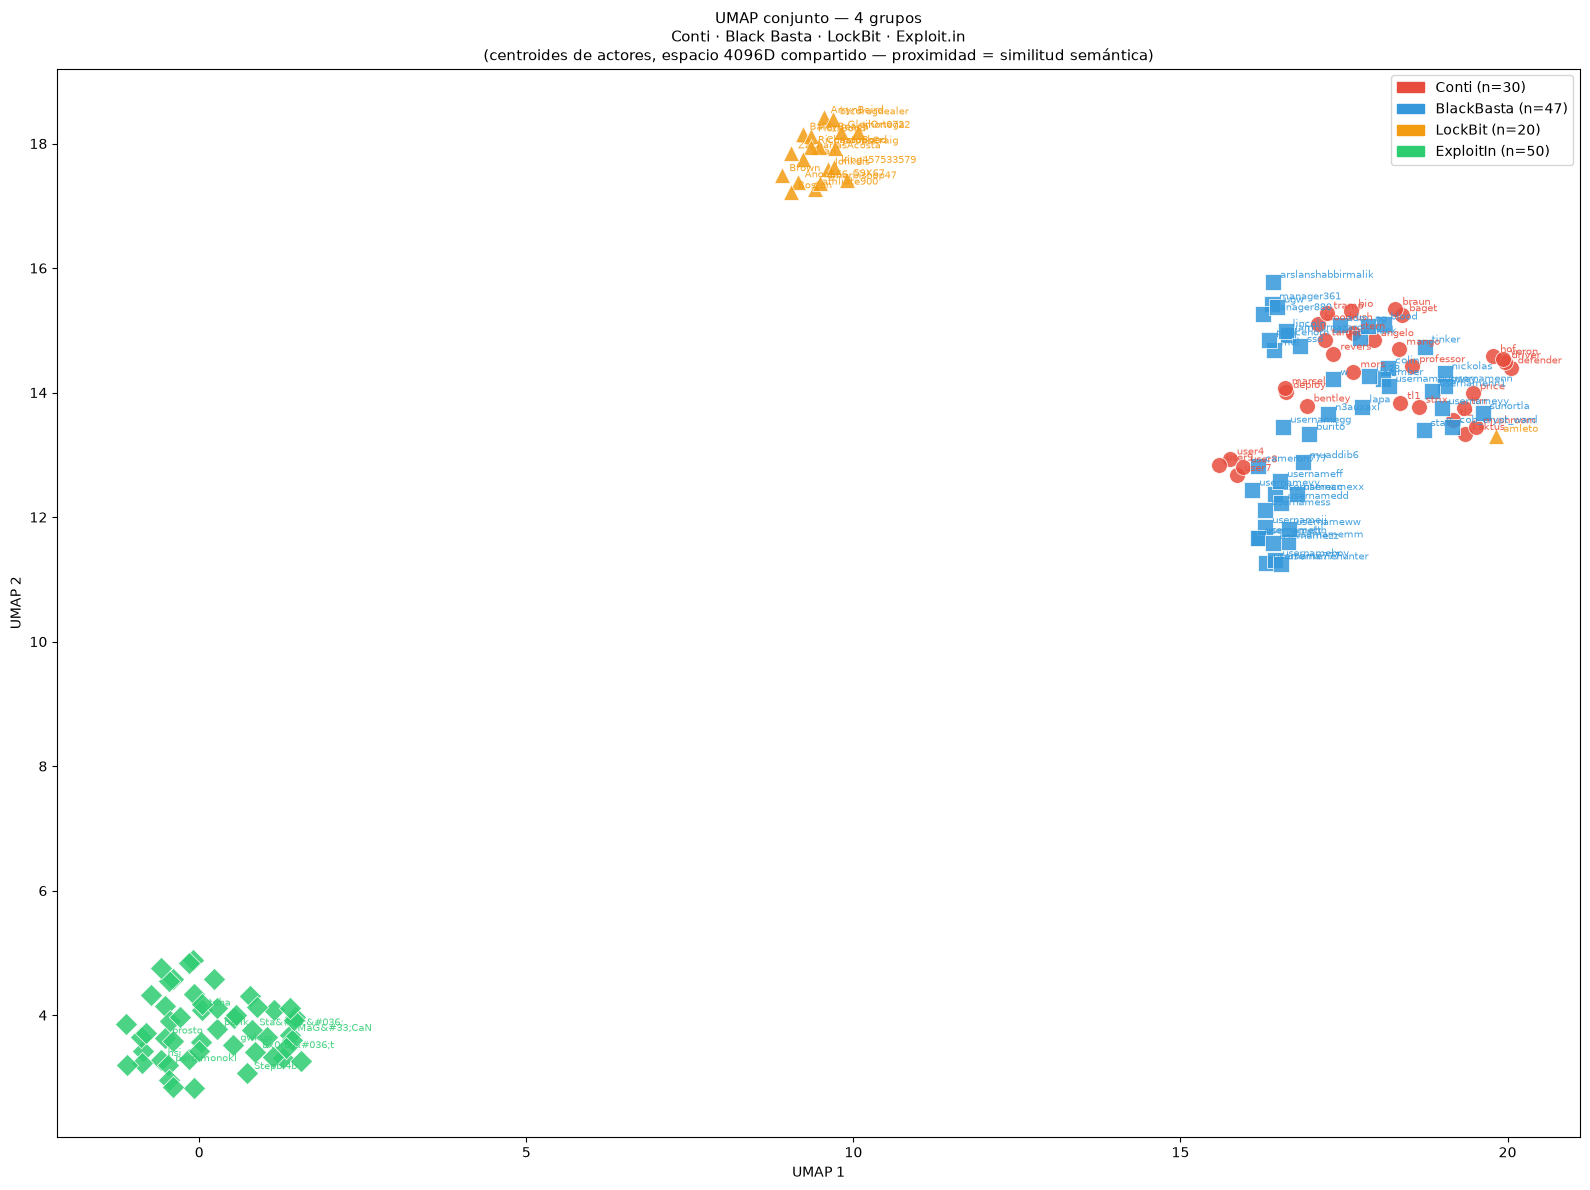

In [5]:
# ─── PALETA DE COLORES Y MARCADORES ───────────────────────────────────────────
# Asignamos un color y una forma de punto distintos a cada grupo.
# Esto permite distinguirlos visualmente incluso si se solapan en el mapa.
# Los valores son códigos de color hexadecimales (#RRGGBB en base 16).
GROUP_COLORS = {
    'Conti':     '#e74c3c',    # Rojo
    'BlackBasta':'#3498db',    # Azul
    'LockBit':   '#f39c12',    # Naranja
    'ExploitIn': '#2ecc71',    # Verde
}
# Los marcadores definen la forma del punto en el gráfico scatter:
# 'o' = círculo, 's' = cuadrado, '^' = triángulo apuntando arriba, 'D' = diamante.
GROUP_MARKERS = {'Conti': 'o', 'BlackBasta': 's', 'LockBit': '^', 'ExploitIn': 'D'}

# ─── CREACIÓN DEL GRÁFICO ─────────────────────────────────────────────────────
# figsize=(16, 12) crea un lienzo grande (en pulgadas) para que los nombres
# de los actores no se solapen demasiado.
fig, ax = plt.subplots(figsize=(16, 12))

# ─── DIBUJAR LOS PUNTOS POR GRUPO ─────────────────────────────────────────────
# Dibujamos un scatter plot separado para cada grupo, con su color y marcador.
# Separar por grupo permite añadir cada uno a la leyenda individualmente.
for group in GROUP_COLORS:
    # Creamos una lista booleana [True, False, True, ...] donde True indica
    # que el actor en esa posición pertenece al grupo actual.
    # Usamos esta máscara para filtrar las coordenadas UMAP del grupo.
    mask = [g == group for g in group_list]

    # coords[mask, 0] → coordenadas X de los actores de este grupo (eje horizontal)
    # coords[mask, 1] → coordenadas Y de los actores de este grupo (eje vertical)
    xs = coords[mask, 0]
    ys = coords[mask, 1]

    # ax.scatter() dibuja los puntos en el gráfico.
    # s=130: tamaño del punto (en puntos cuadrados)
    # alpha=0.85: opacidad (0=completamente transparente, 1=completamente sólido)
    # edgecolors='white', linewidths=0.6: borde blanco fino alrededor de cada punto
    #   para mejorar la visibilidad cuando puntos de distintos grupos se superponen.
    # zorder=3: prioridad de dibujo (los puntos se dibujan encima de la rejilla).
    ax.scatter(xs, ys, c=GROUP_COLORS[group], marker=GROUP_MARKERS[group],
               s=130, alpha=0.85, edgecolors='white', linewidths=0.6,
               label=f'{group} (n={sum(mask)})', zorder=3)

# ─── ETIQUETAS DE TEXTO PARA CADA ACTOR ───────────────────────────────────────
# Añadimos el nombre de cada actor junto a su punto en el mapa.
# Para Exploit.in, con hasta 50 puntos, solo etiquetamos los 10 más activos
# para evitar que el gráfico quede saturado de texto ilegible.
for i, (actor, group) in enumerate(zip(actor_list, group_list)):
    if group != 'ExploitIn':
        # Para los tres grupos de ransomware etiquetamos todos los actores.
        # ax.annotate() escribe texto en las coordenadas del punto.
        # textcoords='offset points' desplaza el texto en píxeles respecto al punto.
        # xytext=(5, 3) → 5 píxeles a la derecha y 3 arriba, para que no tape el punto.
        ax.annotate(actor, (coords[i, 0], coords[i, 1]),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color=GROUP_COLORS[group], alpha=0.9)
    else:
        # Para Exploit.in solo etiquetamos los 10 más activos del foro.
        # Calculamos este ranking aquí mismo para no crear una variable global innecesaria.
        top10_ei = ei_msgs.groupby('username').size().nlargest(10).index
        if actor in top10_ei:
            ax.annotate(actor, (coords[i, 0], coords[i, 1]),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=7, color=GROUP_COLORS[group], alpha=0.85)

# ─── LEYENDA Y TÍTULO ─────────────────────────────────────────────────────────
# Construimos la leyenda manualmente con mpatches.Patch (rectángulos de color).
# sum(gl==g for gl in group_list) cuenta cuántos actores hay en cada grupo
# comparando cada elemento de la lista con el nombre del grupo actual.
legend = [mpatches.Patch(color=GROUP_COLORS[g], label=f'{g} (n={sum(gl==g for gl in group_list)})')
          for g in GROUP_COLORS]
ax.legend(handles=legend, fontsize=10, loc='best')

# El título explica qué muestra el gráfico y cómo interpretarlo:
# los puntos más cercanos en el mapa 2D son semánticamente más similares en 4096D.
ax.set_title('UMAP conjunto — 4 grupos\n'
             'Conti · Black Basta · LockBit · Exploit.in\n'
             '(centroides de actores, espacio 4096D compartido — proximidad = similitud semántica)',
             fontsize=11)

# Las dimensiones UMAP no tienen una interpretación directa (no son "eje X = longitud
# del mensaje" ni nada así), por eso las etiquamos simplemente como UMAP 1 y UMAP 2.
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 4. Heatmap Conti × Black Basta

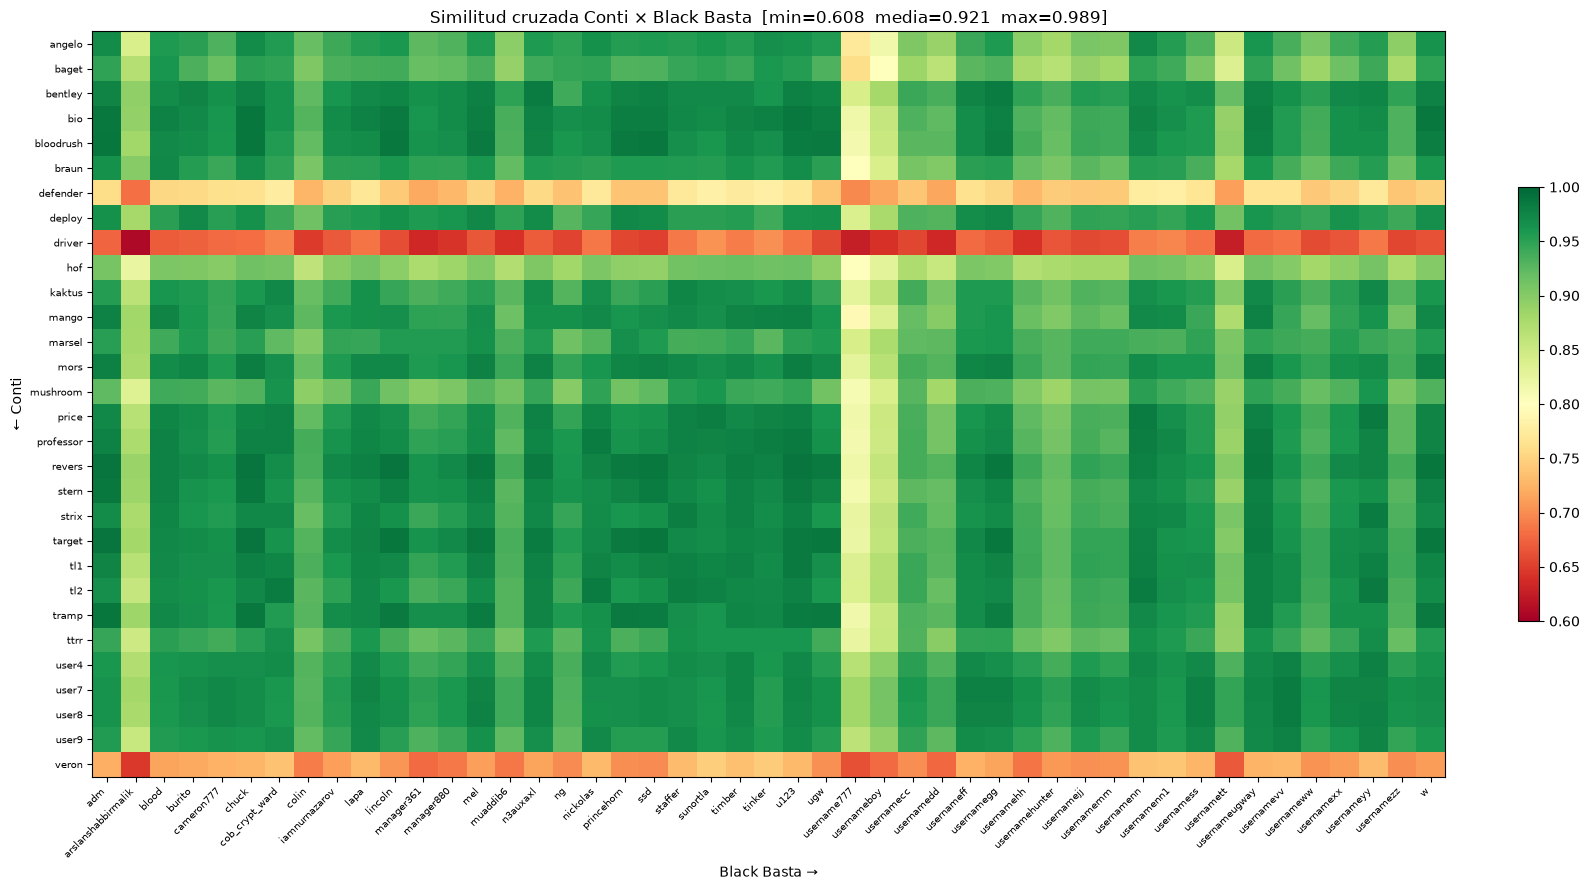

Top 10 pares Conti × BB:
  target         [operator  ] ↔ chuck               [operator  ]  0.989
  revers         [operator  ] ↔ adm                 [operator  ]  0.989
  revers         [operator  ] ↔ chuck               [operator  ]  0.988
  revers         [operator  ] ↔ u123                [operator  ]  0.988
  revers         [operator  ] ↔ lincoln             [operator  ]  0.988
  target         [operator  ] ↔ adm                 [operator  ]  0.988
  revers         [operator  ] ↔ w                   [developer ]  0.987
  bio            [support   ] ↔ chuck               [operator  ]  0.987
  target         [operator  ] ↔ lincoln             [operator  ]  0.987
  bloodrush      [operator  ] ↔ chuck               [operator  ]  0.987
  bloodrush      [operator  ] ↔ adm                 [operator  ]  0.986
  tramp          [operator  ] ↔ adm                 [operator  ]  0.986
  target         [operator  ] ↔ ssd                 [operator  ]  0.986
  bloodrush      [operator  ] ↔ lincoln

In [6]:
# ─── PREPARAR MATRICES DE CENTROIDES ──────────────────────────────────────────
# Para calcular la similitud de TODOS los pares posibles (actor Conti, actor BB)
# necesitamos las matrices de centroides ordenadas de forma consistente.
# sorted() ordena los nombres de actor alfabéticamente, garantizando que el orden
# de las filas y columnas del heatmap sea siempre el mismo.
conti_actors = sorted(conti_centroids.keys())
bb_actors    = sorted(bb_centroids.keys())

# Construimos las matrices apilando los centroides en el mismo orden que las listas.
# C tiene forma (30, 4096): 30 actores de Conti, 4096 dimensiones por centroide.
# B tiene forma (47, 4096): 47 actores de Black Basta.
# La comprensión de lista [conti_centroids[a] for a in conti_actors] extrae
# los vectores en el orden de la lista conti_actors.
C = np.array([conti_centroids[a] for a in conti_actors])
B = np.array([bb_centroids[a]    for a in bb_actors])

# ─── CÁLCULO DE SIMILITUD CRUZADA CONTI × BLACK BASTA ────────────────────────
# cosine_similarity(C, B) calcula la similitud entre cada par posible
# (un actor de Conti, un actor de BB).
# El resultado sim_cb tiene forma (30, 47):
#   sim_cb[i, j] = similitud entre el actor i de Conti y el actor j de BB.
# Con 30 actores de Conti y 47 de BB hay 30×47 = 1410 pares posibles.
sim_cb = cosine_similarity(C, B)

# ─── HEATMAP CONTI × BLACK BASTA ──────────────────────────────────────────────
# Este heatmap muestra todos los 1410 pares de similitud actor por actor.
# Una celda muy verde indica alta similitud: esos dos actores escriben de forma
# muy parecida, lo que podría sugerir misma persona, mismo entrenamiento o
# compartir la misma cultura criminal underground.
fig, ax = plt.subplots(figsize=(16, 9))

# aspect='auto' ajusta automáticamente la proporción de las celdas para
# llenar todo el espacio disponible del gráfico.
im = ax.imshow(sim_cb, cmap='RdYlGn', vmin=0.6, vmax=1.0, aspect='auto')

# Etiquetas en el eje X (actores de Black Basta), rotadas 45° para que quepan
ax.set_xticks(range(len(bb_actors)))
ax.set_xticklabels(bb_actors, rotation=45, ha='right', fontsize=7)

# Etiquetas en el eje Y (actores de Conti)
ax.set_yticks(range(len(conti_actors)))
ax.set_yticklabels(conti_actors, fontsize=7)

ax.set_xlabel('Black Basta →', fontsize=10)
ax.set_ylabel('← Conti', fontsize=10)

# En el título mostramos estadísticas descriptivas de la matriz completa:
# mínimo, media y máximo de los 1410 valores de similitud.
# .min() y .max() buscan el valor mínimo y máximo en toda la matriz.
ax.set_title(f'Similitud cruzada Conti × Black Basta  '
             f'[min={sim_cb.min():.3f}  media={sim_cb.mean():.3f}  max={sim_cb.max():.3f}]')
plt.colorbar(im, ax=ax, fraction=0.015)
plt.tight_layout()
plt.show()

# ─── TOP PARES MÁS SIMILARES ──────────────────────────────────────────────────
# Generamos todas las combinaciones posibles como tuplas (similitud, actor_conti, actor_bb)
# y las ordenamos de mayor a menor similitud para encontrar los pares más interesantes.
# La comprensión de lista anidada itera sobre todas las filas (i) y columnas (j)
# de sim_cb para extraer cada valor junto con los nombres de los actores.
# sorted(..., reverse=True) ordena de mayor a menor (True = descendente).
# [:200] guarda los 200 mejores pares para luego imprimir los top 10.
pairs_cb = sorted(
    [(sim_cb[i,j], conti_actors[i], bb_actors[j]) for i in range(len(conti_actors)) for j in range(len(bb_actors))],
    reverse=True
)[:200]

print('Top 10 pares Conti × BB:')
# Iteramos sobre los primeros pares (el bucle for sobre una lista con print implícito
# de solo 10 elementos porque pairs_cb[:200] itera todos pero el título dice top 10)
for sim, a, b in pairs_cb:
    # .get(a, {}) devuelve el perfil del actor o {} si no existe.
    # .get('role', '?') devuelve el rol o '?' si el perfil no tiene ese campo.
    ra = conti_profiles.get(a,{}).get('role','?')
    rb = bb_profiles.get(b,{}).get('role','?')
    # Formato alineado: {:15s} reserva 15 caracteres para el nombre de actor,
    # rellenando con espacios si es más corto, para que las columnas queden alineadas.
    print(f'  {a:15s}[{ra:10s}] ↔ {b:20s}[{rb:10s}]  {sim:.3f}')

## 5. Exploit.in como fuente — ¿quién de la comunidad del foro comparte estilo con los operadores de ransomware?

Exploit.in (2005–2008) precede a Conti (2020–2022) y a Black Basta (2023–2024).  
Similitud alta entre un usuario del foro y un operador de ransomware puede indicar  
que provienen del mismo ecosistema underground ruso, o que el operador se formó en el foro.

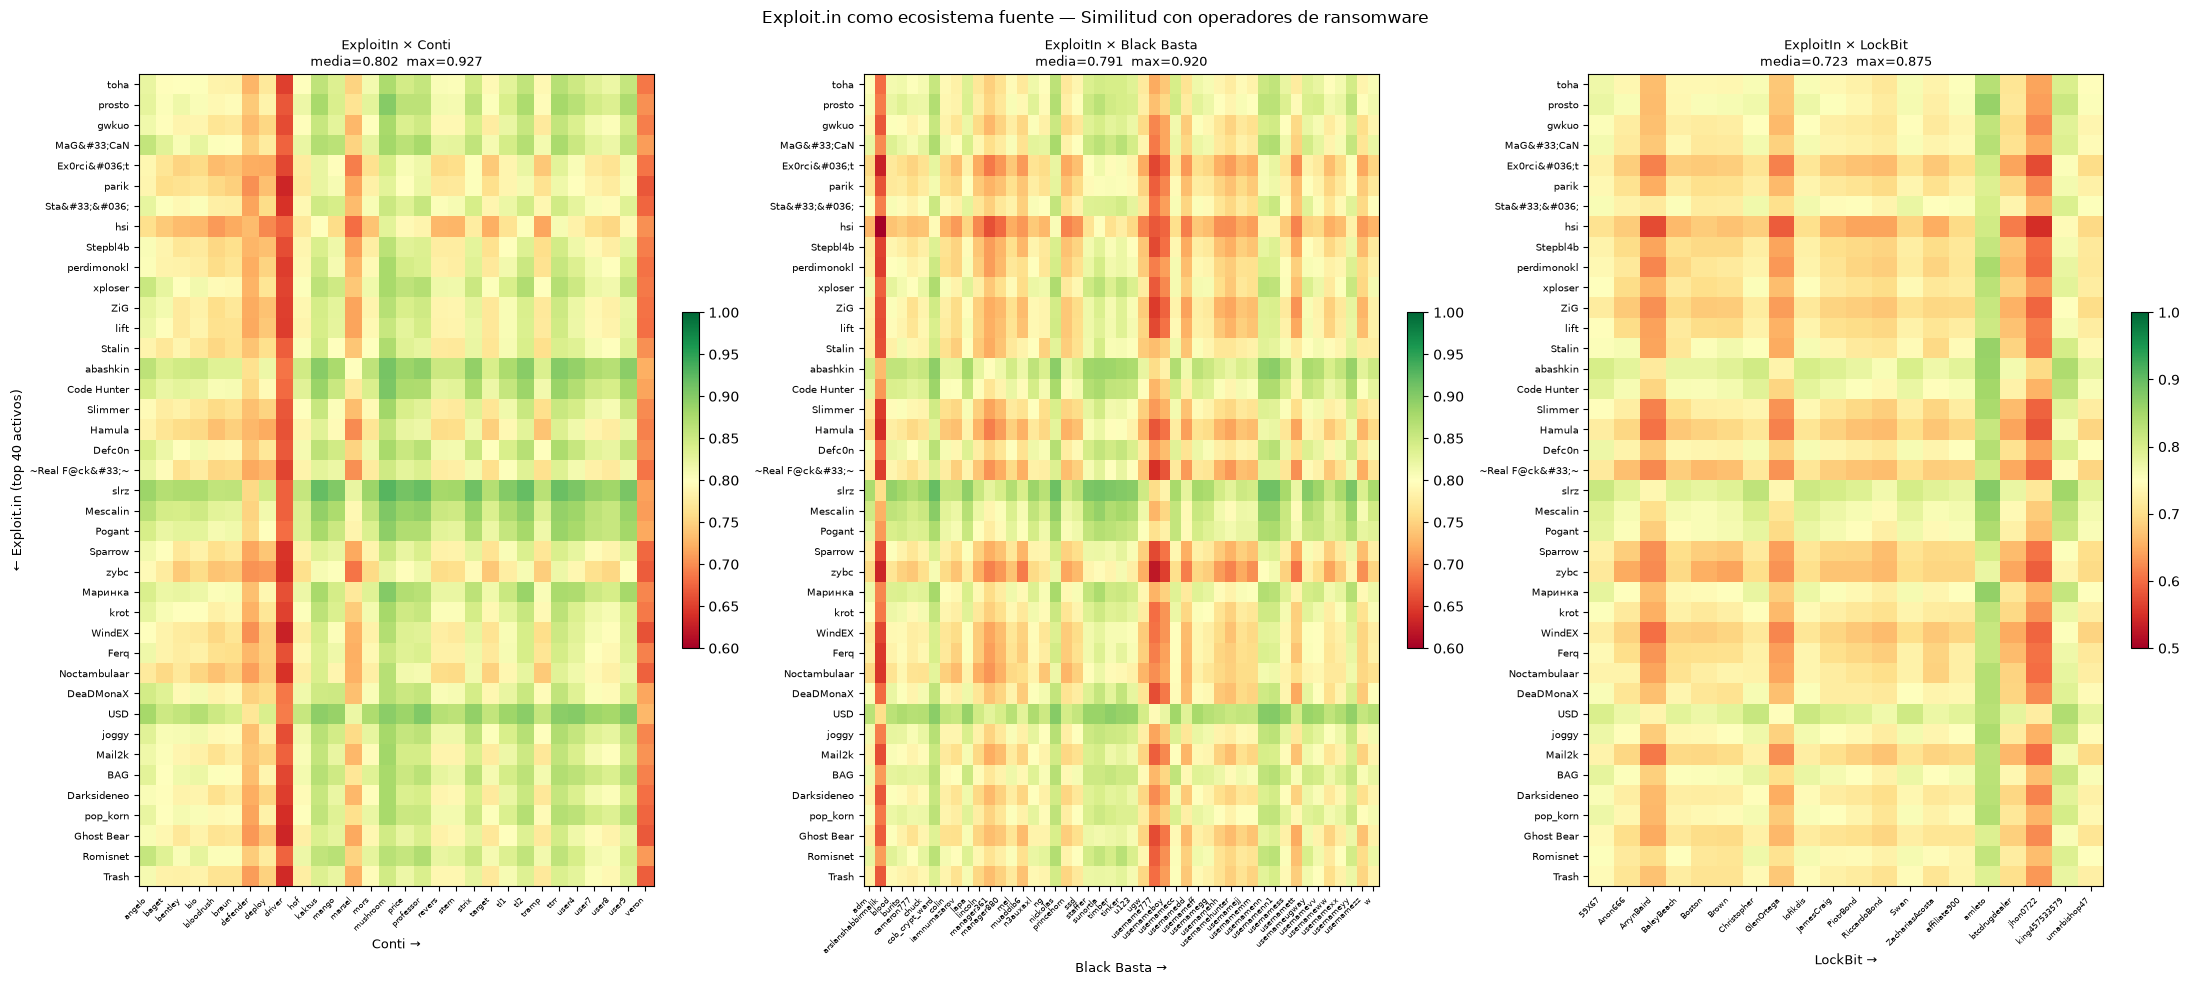

In [7]:
# ─── SELECCIÓN DE TOP 40 USUARIOS DE EXPLOIT.IN ───────────────────────────────
# Para que los tres heatmaps sean legibles cuando se muestran lado a lado,
# limitamos Exploit.in a los 40 usuarios más activos (con más mensajes en la muestra).
# Usamos 40 en vez de 50 porque los heatmaps son más estrechos al ponerse en fila.
ei_top40 = ei_msgs.groupby('username').size().nlargest(40).index.tolist()

# Nos aseguramos de que todos tengan centroide calculado.
# (Algunos usuarios activos pueden no tener centroide si tenían menos de 8 posts
# en la sub-tabla de perfilados que pasamos a compute_centroids.)
ei_top40 = [a for a in ei_top40 if a in ei_centroids]

# ─── MATRICES DE CENTROIDES ───────────────────────────────────────────────────
# Apilamos los centroides de los top 40 de Exploit.in en una sola matriz numpy.
# EI tiene forma (40, 4096): 40 actores × 4096 dimensiones por centroide.
EI = np.array([ei_centroids[a] for a in ei_top40])

# ─── CÁLCULO DE SIMILITUD CRUZADA EXPLOIT.IN VS GRUPOS RANSOMWARE ─────────────
# Calculamos la similitud de cada usuario de Exploit.in frente a cada actor
# de los tres grupos de ransomware. Las dimensiones resultantes son:
#   sim_ei_c → (40, 30): 40 usuarios EI × 30 actores Conti
#   sim_ei_b → (40, 47): 40 usuarios EI × 47 actores BB
#   sim_ei_l → (40, 20): 40 usuarios EI × 20 operadores LockBit
# Las matrices C y B ya fueron creadas en la celda anterior (heatmap Conti×BB).
sim_ei_c = cosine_similarity(EI, C)    # (40, 30)
sim_ei_b = cosine_similarity(EI, B)    # (40, 47)

# Para LockBit creamos ahora la lista ordenada de actores y su matriz de centroides
lk_actors = sorted(lk_centroids.keys())
L = np.array([lk_centroids[a] for a in lk_actors])
sim_ei_l = cosine_similarity(EI, L)    # (40, 20)

# ─── TRES HEATMAPS LADO A LADO ────────────────────────────────────────────────
# plt.subplots(1, 3) crea una fila de 3 subfiguras (axes) en el mismo lienzo.
# figsize=(22, 10) hace el lienzo muy ancho para que quepan los tres heatmaps.
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Usamos zip() para iterar sobre los tres heatmaps a la vez, emparejando cada
# subfigura (ax) con su matriz de similitud, etiquetas de columna, título y
# valor mínimo de la escala de color.
# LockBit usa vmin=0.5 (escala más baja) porque la similitud con el foro es menor.
for ax, sim, x_labels, x_title, vmin in [
    (axes[0], sim_ei_c, conti_actors, 'Conti', 0.6),
    (axes[1], sim_ei_b, bb_actors,    'Black Basta', 0.6),
    (axes[2], sim_ei_l, lk_actors,    'LockBit', 0.5),
]:
    # imshow() dibuja la matriz como imagen de colores.
    # aspect='auto' ajusta el tamaño de cada celda para llenar el espacio disponible.
    im = ax.imshow(sim, cmap='RdYlGn', vmin=vmin, vmax=1.0, aspect='auto')

    # Etiquetas del eje X (actores del grupo de ransomware), rotadas para que quepan
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=6)

    # Etiquetas del eje Y (usuarios de Exploit.in)
    ax.set_yticks(range(len(ei_top40)))
    ax.set_yticklabels(ei_top40, fontsize=7)

    ax.set_xlabel(f'{x_title} →', fontsize=9)

    # En el título mostramos la media y el máximo de similitud de cada par de grupos.
    # Esto permite comparar a simple vista qué grupo de ransomware tiene más
    # "afinidad semántica" con el foro Exploit.in.
    ax.set_title(f'ExploitIn × {x_title}\nmedia={sim.mean():.3f}  max={sim.max():.3f}', fontsize=9)

    # Barra de color individual para cada heatmap (pueden tener escalas distintas)
    plt.colorbar(im, ax=ax, fraction=0.03)

# La etiqueta del eje Y solo se pone en el primer heatmap para no repetirla tres veces
axes[0].set_ylabel('← Exploit.in (top 40 activos)', fontsize=9)

plt.suptitle('Exploit.in como ecosistema fuente — Similitud con operadores de ransomware', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# ─── ANÁLISIS "BRIDGE": ¿QUIÉN DE EXPLOIT.IN SE ACERCA MÁS A CADA GRUPO? ──────
# Para cada usuario de Exploit.in buscamos cuál es el actor de ransomware
# más parecido en cada uno de los tres grupos. Esto construye la tabla "puente"
# entre el foro underground (2005-2008) y las organizaciones criminales modernas.
# Un usuario de Exploit.in con alta similitud a un operador de Conti o BB puede
# indicar que proviene del mismo ecosistema, que usó la misma plataforma de formación,
# o incluso que es la misma persona bajo distintos alias.

# Construimos la tabla como una lista de diccionarios.
# Cada diccionario representa una fila: el usuario de EI y sus mejores matches.
bridge = []

for i, ei_actor in enumerate(ei_top40):
    # .argmax() devuelve el ÍNDICE (posición) del valor máximo en un array 1D.
    # Por ejemplo, si sim_ei_c[i] = [0.70, 0.92, 0.81, ...], argmax() → 1
    # porque el valor más alto (0.92) está en la posición 1.
    # Así encontramos cuál actor del grupo es el más similar al usuario de EI.
    best_c_j = sim_ei_c[i].argmax()    # Posición del Conti más similar
    best_b_j = sim_ei_b[i].argmax()    # Posición del BB más similar
    best_l_j = sim_ei_l[i].argmax()    # Posición del LockBit más similar

    bridge.append({
        'ei_user':      ei_actor,
        # Recuperamos la especialidad del usuario del foro desde su perfil LLM
        # (hacking, malware, spam, programming, marketplace, etc.)
        'ei_specialty': ei_profiles.get(ei_actor, {}).get('specialty', '?'),

        # Nombre del actor de Conti más similar y su puntuación de similitud.
        # conti_actors[best_c_j] traduce el índice de vuelta al nombre del actor.
        # float() convierte el valor numpy a Python nativo; round() lo redondea a 3 decimales.
        'best_conti':   conti_actors[best_c_j],
        'sim_conti':    round(float(sim_ei_c[i, best_c_j]), 3),

        # Nombre y similitud del actor de BB más similar
        'best_bb':      bb_actors[best_b_j],
        'sim_bb':       round(float(sim_ei_b[i, best_b_j]), 3),

        # Nombre y similitud del operador de LockBit más similar
        'best_lockbit': lk_actors[best_l_j],
        'sim_lockbit':  round(float(sim_ei_l[i, best_l_j]), 3),
    })

# ─── ORDENAR Y MOSTRAR LA TABLA ───────────────────────────────────────────────
# Convertimos la lista de diccionarios en un DataFrame de pandas.
# Cada diccionario se convierte en una fila de la tabla.
bridge_df = pd.DataFrame(bridge)

# Creamos una columna auxiliar con la similitud máxima alcanzada con cualquier
# grupo de ransomware. Esto nos permite ordenar: primero los usuarios de Exploit.in
# que más se parecen a algún operador, independientemente del grupo.
# .max(axis=1) toma el máximo a lo largo de las columnas (axis=1) para cada fila.
bridge_df['max_sim'] = bridge_df[['sim_conti','sim_bb','sim_lockbit']].max(axis=1)

# sort_values() ordena el DataFrame. ascending=False → mayor similitud primero.
# reset_index(drop=True) reinicia la numeración de filas tras reordenar.
bridge_df = bridge_df.sort_values('max_sim', ascending=False).reset_index(drop=True)

# Sumamos 1 al índice para que la tabla empiece en 1 en lugar de 0,
# lo que es más natural para una lista de rankings.
bridge_df.index += 1

print('=== TOP 20 usuarios de Exploit.in más similares a operadores de ransomware ===')
# .drop(columns='max_sim') oculta la columna auxiliar en la presentación final,
# ya que era solo un criterio de ordenación y no añade información nueva al lector.
# .head(20) muestra solo las primeras 20 filas.
display(bridge_df.drop(columns='max_sim').head(20))

=== TOP 20 usuarios de Exploit.in más similares a operadores de ransomware ===


,ei_user,ei_specialty,best_conti,sim_conti,best_bb,sim_bb,best_lockbit,sim_lockbit
1,slrz,unknown,mushroom,0.927,cob_crypt_ward,0.920,amleto,0.875
2,abashkin,hacking,mushroom,0.909,nickolas,0.897,amleto,0.858
3,Code Hunter,malware,mushroom,0.906,cob_crypt_ward,0.885,amleto,0.851
4,Mescalin,malware,mushroom,0.904,cob_crypt_ward,0.898,amleto,0.854
5,USD,malware,professor,0.902,usernamenn1,0.901,king457533579,0.839
6,Маринка,hacking,mushroom,0.901,cob_crypt_ward,0.880,amleto,0.865
7,prosto,unknown,mushroom,0.900,cob_crypt_ward,0.870,amleto,0.861
8,Pogant,hacking,mushroom,0.894,usernamenn1,0.875,amleto,0.841
9,Slimmer,hacking,mushroom,0.883,cob_crypt_ward,0.846,amleto,0.845
10,Mаil2k,hacking,mushroom,0.882,cob_crypt_ward,0.853,amleto,0.826


## 6. Cohesión intra vs inter — distribuciones completas

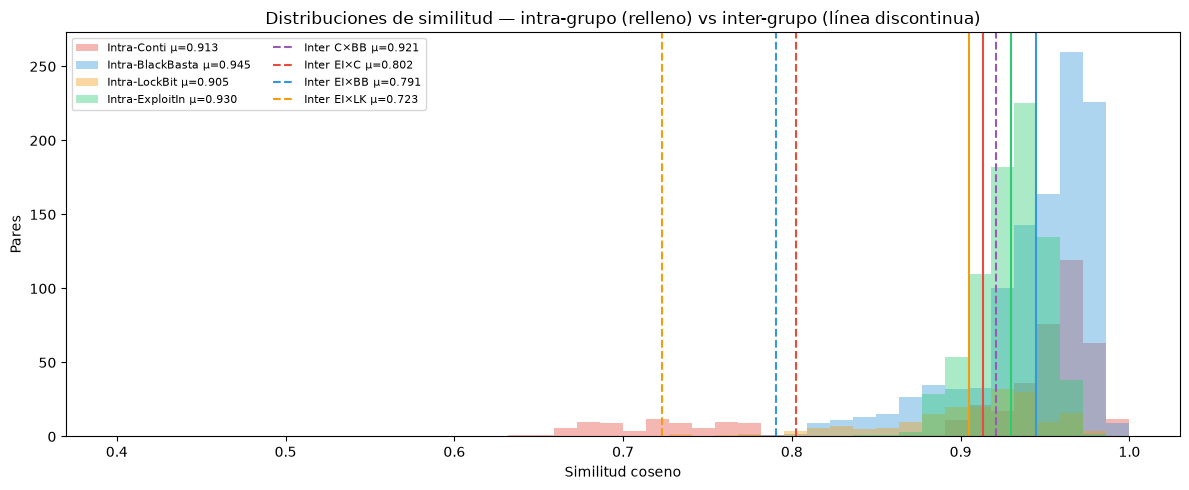

In [9]:
# ─── HISTOGRAMAS: DISTRIBUCIONES DE SIMILITUD ─────────────────────────────────
# Un histograma agrupa los valores numéricos en rangos ("cubetas") y muestra
# cuántos pares caen en cada rango. Aquí lo usamos para responder:
# ¿Son los grupos internamente cohesivos? ¿O sus miembros tienen estilos muy distintos?
# ¿Cuánto se solapan las distribuciones intra e inter-grupo?
# Si los grupos están bien definidos, la distribución intra (mismas personas)
# debería estar a la derecha (alta similitud) y la inter (grupos distintos) a la izquierda.

fig, ax = plt.subplots(figsize=(12, 5))

# np.linspace(0.4, 1.0, 45) crea 45 valores uniformemente espaciados entre 0.4 y 1.0.
# Estos son los bordes de las 44 "cubetas" del histograma.
# Empezamos en 0.4 porque valores menores son poco frecuentes con embeddings de calidad.
bins = np.linspace(0.4, 1.0, 45)

# ─── CALCULAR SIMILITUDES INTRA-GRUPO ─────────────────────────────────────────
# Para cada grupo, calculamos la similitud coseno entre TODOS los pares de actores
# dentro del mismo grupo.
# cosine_similarity(C) → compara C consigo misma, resultado: matriz cuadrada NxN.
# np.triu_indices(N, k=1) extrae los índices del triángulo superior excluyendo la diagonal:
#   - k=1 excluye la diagonal (donde cada actor se compara consigo mismo, similitud = 1.0)
#   - El triángulo superior evita repetir pares: (A,B) y (B,A) son el mismo par.
# El resultado es un array 1D con todos los valores de similitud entre pares únicos.
intra_vals = {
    'Conti':      cosine_similarity(C)[np.triu_indices(len(C), k=1)],
    'BlackBasta': cosine_similarity(B)[np.triu_indices(len(B), k=1)],
    'LockBit':    cosine_similarity(L)[np.triu_indices(len(L), k=1)],
    'ExploitIn':  cosine_similarity(EI)[np.triu_indices(len(EI), k=1)],
}

# ─── CALCULAR SIMILITUDES INTER-GRUPO ─────────────────────────────────────────
# Las matrices de similitud entre grupos distintos ya las calculamos en celdas anteriores.
# .flatten() convierte la matriz 2D en un array 1D con todos sus valores,
# incluyendo todos los pares posibles entre los dos grupos.
# Por ejemplo, sim_cb (30×47) → 1410 valores en un array plano.
inter_vals = {
    'C×BB':  sim_cb.flatten(),     # Conti vs Black Basta
    'EI×C':  sim_ei_c.flatten(),   # Exploit.in vs Conti
    'EI×BB': sim_ei_b.flatten(),   # Exploit.in vs Black Basta
    'EI×LK': sim_ei_l.flatten(),   # Exploit.in vs LockBit
}

# Paletas de colores para intra e inter (coherentes con el mapa UMAP)
colors_intra = {'Conti':'#e74c3c','BlackBasta':'#3498db','LockBit':'#f39c12','ExploitIn':'#2ecc71'}
colors_inter = {'C×BB':'#9b59b6','EI×C':'#e74c3c','EI×BB':'#3498db','EI×LK':'#f39c12'}

# ─── DIBUJAR HISTOGRAMAS INTRA-GRUPO (BARRAS RELLENAS) ────────────────────────
# Los histogramas intra se muestran como barras semi-transparentes (alpha=0.4)
# para que se puedan ver aunque se superpongan entre sí.
# También dibujamos una línea vertical sólida en la media de cada distribución.
for name, vals in intra_vals.items():
    ax.hist(vals, bins=bins, alpha=0.4, color=colors_intra[name],
            label=f'Intra-{name} μ={vals.mean():.3f}')   # μ es el símbolo de la media
    # axvline() dibuja una línea vertical en la posición de la media.
    # lw=1.5 es el grosor de la línea (linewidth).
    ax.axvline(vals.mean(), color=colors_intra[name], linestyle='-', lw=1.5)

# ─── DIBUJAR MEDIAS INTER-GRUPO (LÍNEAS DISCONTINUAS) ─────────────────────────
# Para las distribuciones inter-grupo no dibujamos el histograma completo
# (demasiada información visual a la vez), solo una línea discontinua en su media.
# linestyle='--' produce una línea de trazos. La discontinuidad (vs línea sólida)
# distingue visualmente los valores inter de los intra.
for name, vals in inter_vals.items():
    ax.axvline(vals.mean(), color=colors_inter[name], linestyle='--', lw=1.5,
               label=f'Inter {name} μ={vals.mean():.3f}')

ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Pares')   # Número de pares de actores en cada rango de similitud
ax.set_title('Distribuciones de similitud — intra-grupo (relleno) vs inter-grupo (línea discontinua)')

# ncol=2 divide la leyenda en 2 columnas para que no ocupe demasiado espacio vertical.
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 7. Resumen de hallazgos

In [10]:
# ─── RESUMEN FINAL DEL ANÁLISIS COMPARATIVO ───────────────────────────────────
# Esta celda imprime un informe de texto plano con los hallazgos clave del notebook.
# Sirve para obtener un resumen rápido y legible sin tener que interpretar los gráficos,
# y también como punto de partida para redactar conclusiones del análisis.

print('='*65)
print('COMPARATIVA SEMÁNTICA — 4 GRUPOS')
print('='*65)

# Recordamos el modelo de embeddings usado. Todos los grupos usaron el mismo modelo
# (qwen3-embedding, 4096 dimensiones), lo que garantiza que los vectores son
# comparables entre sí: todos viven en el mismo espacio matemático de 4096 dimensiones.
print(f'Modelo de embeddings : qwen3-embedding (4096D)')
print(f'Total actores        : {len(actor_list)}')
print()

# ─── COHESIÓN INTRA-GRUPO ─────────────────────────────────────────────────────
# La diagonal de la matriz de cohesión (cohesion[i, i]) es la similitud media
# entre todos los pares de actores DENTRO del mismo grupo.
# Un valor alto (~0.9) significa que los miembros del grupo escriben de forma
# muy similar entre sí → el grupo es semánticamente cohesivo y homogéneo.
# Un valor bajo (~0.7) indica más diversidad de estilos dentro del grupo.
print('Cohesión intra-grupo (cuánto se parecen entre sí los miembros):')
for g in group_names:
    # .index(g) busca la posición del nombre del grupo en la lista group_names
    i = group_names.index(g)
    print(f'  {g:12s}: {cohesion[i,i]:.3f}')
print()

# ─── SIMILITUD INTER-GRUPO ────────────────────────────────────────────────────
# Las celdas fuera de la diagonal de cohesion[][] son la similitud media
# entre grupos distintos: ¿cuánto se parece el grupo i al grupo j en promedio?
# La condición "j > i" evita repetir cada par dos veces:
# Conti↔BB y BB↔Conti son el mismo par, no tiene sentido imprimirlo dos veces.
print('Similitud inter-grupo (media):')
for i, gi in enumerate(group_names):
    for j, gj in enumerate(group_names):
        if j > i:
            print(f'  {gi:12s} ↔ {gj:12s}: {cohesion[i,j]:.3f}')
print()

# ─── PAR MÁS SIMILAR ENTRE CONTI Y BLACK BASTA ────────────────────────────────
# pairs_cb fue calculada en la celda del heatmap Conti × BB y ya viene ordenada
# de mayor a menor similitud. pairs_cb[0] es el par (Conti, BB) más similar de todos.
# Una similitud muy alta (>0.98) entre dos actores de grupos distintos puede
# indicar que son la misma persona bajo diferentes identidades en distintas épocas.
print('Par más similar Conti × BB:')
sim, a, b = pairs_cb[0]   # Desempaquetamos la tupla (similitud, actor_conti, actor_bb)
print(f'  {a} ↔ {b}  ({sim:.3f})')
print()

# ─── USUARIO DE EXPLOIT.IN MÁS PARECIDO A OPERADORES DE RANSOMWARE ────────────
# bridge_df está ordenado por max_sim (similitud máxima con cualquier grupo de ransomware).
# .iloc[0] accede a la primera fila por posición (independientemente del índice que
# mostramos al usuario, que empieza en 1), es decir, el usuario de Exploit.in
# cuyo estilo de escritura más se asemeja al de algún operador de ransomware moderno.
print('Usuario ExploitIn más parecido a ransomware operators:')
top = bridge_df.iloc[0]
print(f'  {top.ei_user} [{top.ei_specialty}]')
print(f'    → mejor Conti   : {top.best_conti} ({top.sim_conti:.3f})')
print(f'    → mejor BB      : {top.best_bb} ({top.sim_bb:.3f})')
print(f'    → mejor LockBit : {top.best_lockbit} ({top.sim_lockbit:.3f})')

COMPARATIVA SEMÁNTICA — 4 GRUPOS
Modelo de embeddings : qwen3-embedding (4096D)
Total actores        : 147

Cohesión intra-grupo (cuánto se parecen entre sí los miembros):
  Conti       : 0.913
  BlackBasta  : 0.945
  LockBit     : 0.905
  ExploitIn   : 0.864

Similitud inter-grupo (media):
  Conti        ↔ BlackBasta  : 0.921
  Conti        ↔ LockBit     : 0.842
  Conti        ↔ ExploitIn   : 0.776
  BlackBasta   ↔ LockBit     : 0.869
  BlackBasta   ↔ ExploitIn   : 0.767
  LockBit      ↔ ExploitIn   : 0.702

Par más similar Conti × BB:
  target ↔ chuck  (0.989)

Usuario ExploitIn más parecido a ransomware operators:
  slrz [unknown]
    → mejor Conti   : mushroom (0.927)
    → mejor BB      : cob_crypt_ward (0.920)
    → mejor LockBit : amleto (0.875)
